In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import os
import torch
import seaborn as sns
import copy
from scipy.stats import pearsonr

In [33]:
import sys
sys.path.append('../code/BalancingControl')
import tmaze_utils as tu
import inference_utils as iu
import misc

torch threads 1


In [3]:
training_file = os.path.join('raw_data', 'Training.csv')

In [4]:
training_csv = pd.read_csv(training_file, delimiter=';')
print(len(training_csv.columns))

181


In [5]:
# cutting out empty rows
training_csv = training_csv[1:18]

# note that animal 21 was excluded
training_csv = training_csv.drop(14)
print(training_csv.columns)

Index(['Rat Nr.', '1st', '2nd', '3rd', '4th', '5th', 'performance', '1st.1',
       '2nd.1', '3rd.1',
       ...
       '3rd.28', '4th.28', '5th.28', 'performance.28', '1st.29', '2nd.29',
       '3rd.29', '4th.29', '5th.29', 'performance.29'],
      dtype='object', length=181)


In [6]:
training_csv

,Rat Nr.,1st,2nd,3rd,4th,5th,performance,1st.1,2nd.1,3rd.1,...,3rd.28,4th.28,5th.28,performance.28,1st.29,2nd.29,3rd.29,4th.29,5th.29,performance.29
1,24.0,R,Lx,Lx,Lx,Lx,0.0,R,Lx,Lv,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,25.0,R,R,R,Lv,Lv,40.0,R,Lv,Lv,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,26.0,Lx,R,R,Lv,Lv,40.0,R,Lx,Lv,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,27.0,Lx,R,Lv,Lv,Lv,60.0,Lx,Lx,Lv,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,32.0,Lv,Lv,Lv,Lv,Lv,100.0,R,Lv,Lv,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,33.0,R,R,Lx,Lx,Lx,0.0,LX,LX,LX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,34.0,Lv,R,R,Lv,Lv,60.0,R,LX,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,35.0,R,Lx,Lx,Lv,Lv,40.0,R,R,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,44.0,R,R,R,Lv,R,20.0,R,R,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,45.0,Lx,Lx,Lx,Lx,Lx,0.0,R,LX,LX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# encoding:
# during training
# R = right -> wrong = no reward
# Lx = left, didnt consume reward -> no reward
# Lv = left, consumed reward -> reward
# during testing
# U = unbaited arm, wrong choice
# B = baited arm, correct choice

mapping = {"R": 0, "LX": 1, "LV": 1, "U": 1, "B": 0}

reward_mapping = {"R": 0, "LX": 0, "LV": 2, "B": 2, "U": 0}

# animals 24, 25, 26, 27, 32, 33, 34, 35 are alcohol-cie, and animals 44, 45, 46, 47, 20, 21, 38, 39 are controls

animal_nr = list(training_csv['Rat Nr.'])

groups = {"cie": animal_nr[:8], "control": animal_nr[8:]}

print(groups)

n_animals = len(animal_nr)

{'cie': [24.0, 25.0, 26.0, 27.0, 32.0, 33.0, 34.0, 35.0], 'control': [44.0, 45.0, 46.0, 47.0, 20.0, 38.0, 39.0]}


In [8]:
training_trials = 75
test_trials = 5

total_trials = 2*(training_trials+test_trials)

In [9]:
training_csv[training_csv["Rat Nr."]==animal_nr[2]].iterrows

def convert_letter_actions_to_numbers(df, k):

    actions = np.zeros((total_trials, 1)) - 1
    mask = np.zeros((total_trials,1)).astype(bool)
    observations = np.zeros((total_trials, 2))
    rewards = np.ones((total_trials, 2))

    count = 0
    letter = None
    for entry in np.array(df[df['Rat Nr.'] == k])[0]:
        if type(entry) != str:
            pass
        else:
            if entry.upper() in ["LX", "LV", "R"]:
                pass
            elif entry.upper() in ["B", "U"] and letter in ["LX", "LV", "R"]:
                if count < training_trials:
                    count = training_trials
                else:
                    count = 2*training_trials + test_trials
            letter = entry.upper()
            mask[count] = True
            actions[count] = mapping[letter]
            observations[count,1] = mapping[letter] + 1
            rewards[count,1] = reward_mapping[letter]
            count += 1

    return actions, mask, observations, rewards


def create_group_data(group_name, df):

    group_size = len(groups[group_name])
    data_list = []
    plot_dict = {"animal": np.zeros(total_trials*group_size), "correct": np.zeros(total_trials*group_size), "valid": np.zeros(total_trials*group_size).astype(bool), 
                 "group": [group_name]*total_trials*group_size, "trial": np.zeros(total_trials*group_size), "trial_type": [], "training_type": [], "detailed_trial_type": []}

    for i,s in enumerate(groups[group_name]):
        print(s)
        actions, mask, observations, rewards = convert_letter_actions_to_numbers(df, s)
        data_list.append({"subject": torch.tensor([s]), "actions": torch.from_numpy(actions).long(), "observations": torch.from_numpy(observations).long(), 
                          "rewards":torch.from_numpy(rewards).long(), "states": torch.from_numpy(observations).long(), 'valid': torch.from_numpy(mask), 
                          "context": torch.tensor(([0]*training_trials+[1]*test_trials)*2).long()})
        plot_dict["animal"][i*total_trials:(i+1)*total_trials] = s
        plot_dict["correct"][i*total_trials:(i+1)*total_trials] = rewards[:,1]//2
        plot_dict["valid"][i*total_trials:(i+1)*total_trials] = mask[...,0]
        plot_dict["trial"][i*total_trials:(i+1)*total_trials] = list(range(total_trials))
        plot_dict["trial_type"] += ["training"]*training_trials+["early test"]*test_trials+["training"]*training_trials+["late test"]*test_trials
        plot_dict["training_type"] += ["early training"]*training_trials+["test"]*test_trials+["late training"]*training_trials+["test"]*test_trials
        plot_dict["detailed_trial_type"] += ["early training"]*training_trials+["early test"]*test_trials+["late training"]*training_trials+["late test"]*test_trials


    return data_list, plot_dict

In [10]:
total_training_trials = training_trials*2

def convert_letter_actions_to_numbers_training_only(df, k):

    actions = np.zeros((total_training_trials, 1)) - 1
    mask = np.zeros((total_training_trials,1)).astype(bool)
    observations = np.zeros((total_training_trials, 2))
    rewards = np.ones((total_training_trials, 2))

    count = 0
    letter = None
    for entry in np.array(df[df['Rat Nr.'] == k])[0]:
        if type(entry) != str:
            pass
        else:
            if entry.upper() in ["B", "U"] and letter in ["LX", "LV", "R"]:
                if count < training_trials:
                    count = training_trials
                else:
                    pass #count = 2*training_trials# + test_trials
                # print(count)
            elif entry.upper() in ["LX", "LV", "R"]:
                letter = entry.upper()
                mask[count] = True
                actions[count] = mapping[letter]
                observations[count,1] = mapping[letter] + 1
                rewards[count,1] = reward_mapping[letter]
                count += 1

    return actions, mask, observations, rewards


def create_group_data_training_only(group_name, df):

    group_size = len(groups[group_name])
    data_list = []
    plot_dict = {"animal": np.zeros(total_training_trials*group_size), "correct": np.zeros(total_training_trials*group_size), "valid": np.zeros(total_training_trials*group_size).astype(bool), 
                 "group": [group_name]*total_training_trials*group_size, "trial": np.zeros(total_training_trials*group_size), "trial": np.zeros(total_trials*group_size), "trial_type": [], "training_type": [], "detailed_trial_type": []}

    for i,s in enumerate(groups[group_name]):
        print(s)
        actions, mask, observations, rewards = convert_letter_actions_to_numbers_training_only(df, s)
        data_list.append({"subject": torch.tensor([s]), "actions": torch.from_numpy(actions).long(), "observations": torch.from_numpy(observations).long(), 
                          "rewards":torch.from_numpy(rewards).long(), "states": torch.from_numpy(observations).long(), 'valid': torch.from_numpy(mask), 
                          "context": torch.tensor(([0]*training_trials)*2).long()})
        plot_dict["animal"][i*total_training_trials:(i+1)*total_training_trials] = s
        plot_dict["correct"][i*total_training_trials:(i+1)*total_training_trials] = rewards[:,1]//2
        plot_dict["valid"][i*total_training_trials:(i+1)*total_training_trials] = mask[...,0]
        plot_dict["trial"][i*total_training_trials:(i+1)*total_training_trials] = list(range(total_training_trials))
        plot_dict["trial_type"] += ["training"]*training_trials*2
        plot_dict["training_type"] += ["early training"]*training_trials+["late training"]*training_trials
        plot_dict["detailed_trial_type"] += ["early training"]*training_trials+["late training"]*training_trials


    return data_list, plot_dict

In [11]:
group_name = "control"

data_list_control, plot_dict_control = create_group_data(group_name, training_csv)

base_dir = "processed_data"
fname_data = os.path.join(base_dir, f"TMaze_{group_name}_structured_data.json")
structured_data_control = tu.restructure_behavioral_data(data_list_control)
misc.save_file(structured_data_control, fname_data)

fname_data = os.path.join(base_dir, f"TMaze_{group_name}_structured_data_context.json")
structured_data_control_context = tu.restructure_behavioral_data(data_list_control, use_context=True)
misc.save_file(structured_data_control_context, fname_data)

data_list_control_training_only, plot_dict_control_training_only = create_group_data_training_only(group_name, training_csv)

fname_data = os.path.join(base_dir, f"TMaze_{group_name}_structured_data_training_only.json")
structured_data_control_training_only = tu.restructure_behavioral_data(data_list_control_training_only)
misc.save_file(structured_data_control_training_only, fname_data)


44.0
45.0
46.0
47.0
20.0
38.0
39.0
44.0
45.0
46.0
47.0
20.0
38.0
39.0


c:\Users\sarah\Documents\GitHub\TMaze\cie_task\../code/BalancingControl\tmaze_utils.py:122: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data_val = torch.cat([torch.tensor(d["valid"]) for d in data], dim=-1)


In [12]:
group_name = "cie"

data_list_cie, plot_dict_cie = create_group_data(group_name, training_csv)

fname_data = os.path.join(base_dir, f"TMaze_{group_name}_structured_data.json")
structured_data_cie = tu.restructure_behavioral_data(data_list_cie)
misc.save_file(structured_data_cie, fname_data)

fname_data = os.path.join(base_dir, f"TMaze_{group_name}_structured_data_context.json")
structured_data_cie_context = tu.restructure_behavioral_data(data_list_cie, use_context=True)
misc.save_file(structured_data_cie_context, fname_data)

data_list_cie_training_only, plot_dict_cie_training_only = create_group_data_training_only(group_name, training_csv)

fname_data = os.path.join(base_dir, f"TMaze_{group_name}_structured_data_training_only.json")
structured_data_cie_training_only = tu.restructure_behavioral_data(data_list_cie_training_only)
misc.save_file(structured_data_cie_training_only, fname_data)

24.0
25.0
26.0
27.0
32.0
33.0
34.0
35.0


24.0
25.0
26.0
27.0
32.0
33.0
34.0
35.0


In [13]:
plot_dict = {"animal": np.append(plot_dict_control["animal"], plot_dict_cie["animal"]), "correct": np.append(plot_dict_control["correct"], plot_dict_cie["correct"]), 
             "group": plot_dict_control["group"] + plot_dict_cie["group"], "valid": np.append(plot_dict_control["valid"], plot_dict_cie["valid"]),
             "trial": np.append(plot_dict_control["trial"], plot_dict_cie["trial"]), 
             "trial_type": plot_dict_control["trial_type"]+plot_dict_cie["trial_type"],
             "training_type": plot_dict_control["training_type"]+plot_dict_cie["training_type"],
             "detailed_trial_type": plot_dict_control["detailed_trial_type"]+plot_dict_cie["detailed_trial_type"]}

In [14]:
plot_df = pd.DataFrame(plot_dict)

In [15]:
base_dir = "processed_data"
plot_df_file = os.path.join(base_dir, "plot_df.csv")
plot_df.to_csv(plot_df_file)

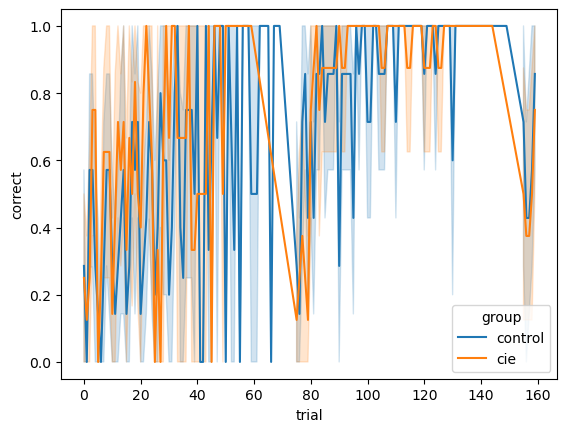

In [16]:
plt.figure()
sns.lineplot(data=plot_df[plot_df["valid"]==True], x="trial", y="correct", hue="group")
plt.show()

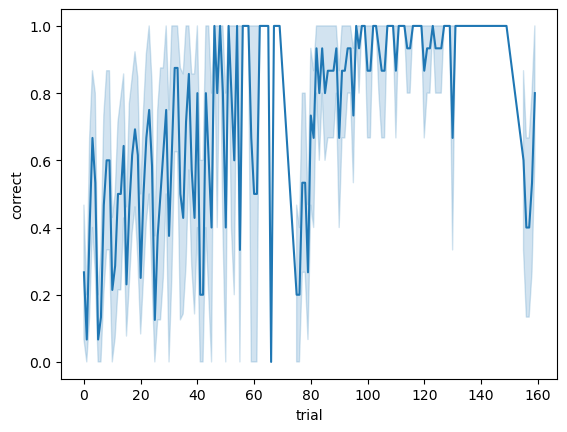

In [17]:
plt.figure()
sns.lineplot(data=plot_df[plot_df["valid"]==True], x="trial", y="correct")
plt.show()

In [18]:
summary_df = plot_df[plot_df["valid"]==True].groupby(["animal", "group", "trial_type"])["correct"].mean()

In [19]:
pd.DataFrame(summary_df)

correct
animal group   trial_type          
20.0   control early test  0.400000
               late test   0.400000
               training    0.633333
24.0   cie     early test  0.200000
               late test   0.400000
               training    0.727273
25.0   cie     early test  0.200000
               late test   0.400000
               training    0.892308
26.0   cie     early test  0.200000
               late test   0.200000
               training    0.811111
27.0   cie     early test  0.400000
               late test   0.800000
               training    0.914286
32.0   cie     early test  0.400000
               late test   0.600000
               training    0.826667
33.0   cie     early test  0.000000
               late test   0.200000
               training    0.666667
34.0   cie     early test  0.200000
               late test   0.800000
               training    0.853333
35.0   cie     early test  0.200000
               late test   0.600000
               training    0.853333
38.0   control early test  0.600000
               late test   0.800000
               training    0.666667
39.0   control early test  0.400000
               late test   0.400000
               training    0.850000
44.0   control early test  0.200000
               late test   0.600000
               training    0.853333
45.0   control early test  0.200000
               late test   1.000000
               training    0.700000
46.0   control early test  1.000000
               late test   0.200000
               training    0.771429
47.0   control early test  0.600000
               late test   0.800000
               training    0.656000

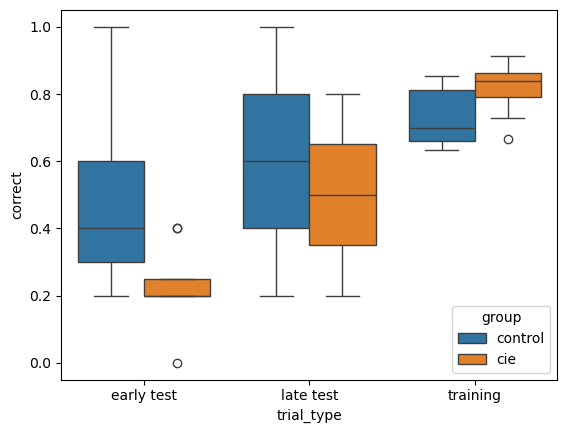

In [20]:
plt.figure()
sns.boxplot(data=pd.DataFrame(summary_df), x="trial_type", y="correct", hue="group")
plt.show()

In [21]:
training_summary_df = plot_df[plot_df["valid"]==True].groupby(["animal", "group", "training_type"])["correct"].mean()

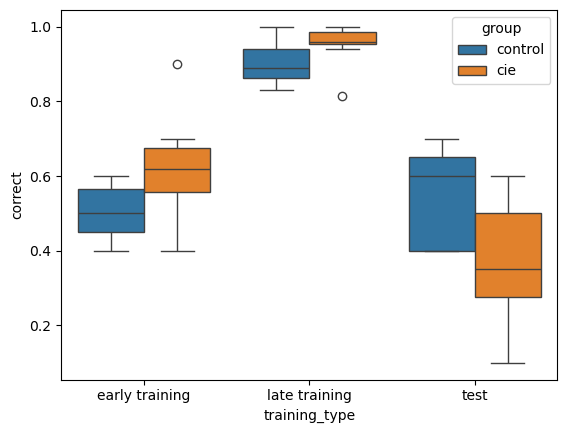

In [22]:
plt.figure()
sns.boxplot(data=pd.DataFrame(training_summary_df), x="training_type", y="correct", hue="group")
plt.show()

In [23]:
detailed_summary_df = plot_df[plot_df["valid"]==True].groupby(["animal", "group", "detailed_trial_type"])["correct"].mean()

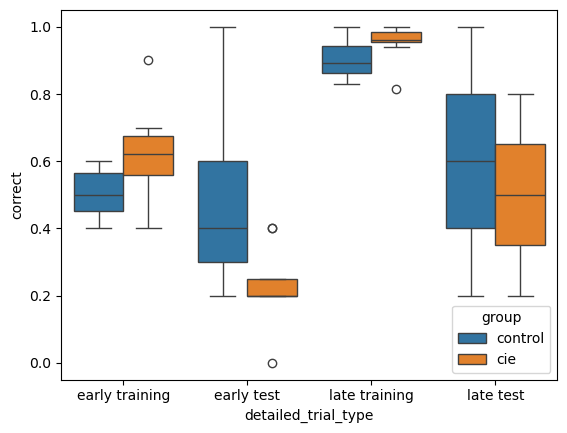

In [24]:
plt.figure()
sns.boxplot(data=pd.DataFrame(detailed_summary_df), x="detailed_trial_type", y="correct", hue="group", order=["early training", "early test", "late training", "late test"])
plt.show()

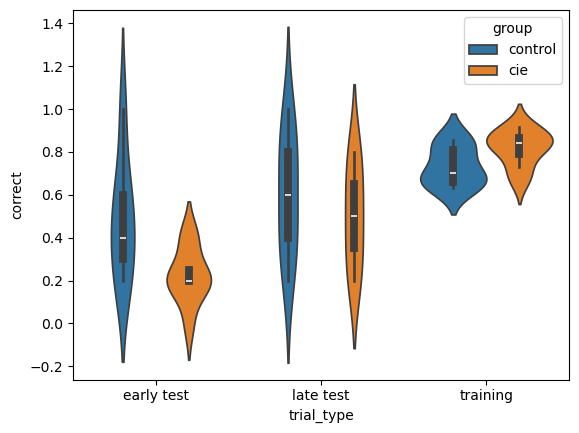

In [25]:
plt.figure()
sns.violinplot(data=pd.DataFrame(summary_df), x="trial_type", y="correct", hue="group")
plt.show()

In [26]:
control_df = pd.DataFrame(plot_df[plot_df["group"]=="control"].groupby(["animal", "detailed_trial_type"])["correct"].mean())

In [37]:
control_early_test_accuracy = plot_df[plot_df["detailed_trial_type"]=="early test"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
control_late_test_accuracy = plot_df[plot_df["detailed_trial_type"]=="late test"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
control_early_training_accuracy = plot_df[plot_df["detailed_trial_type"]=="early training"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
control_late_training_accuracy = plot_df[plot_df["detailed_trial_type"]=="late training"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
control_early_test_first_choice = plot_df[plot_df["trial"]==75][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
control_late_test_first_choice = plot_df[plot_df["trial"]==155][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values

C:\Users\sarah\AppData\Local\Temp\ipykernel_9104\225053649.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  control_early_test_accuracy = plot_df[plot_df["detailed_trial_type"]=="early test"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
C:\Users\sarah\AppData\Local\Temp\ipykernel_9104\225053649.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  control_late_test_accuracy = plot_df[plot_df["detailed_trial_type"]=="late test"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
C:\Users\sarah\AppData\Local\Temp\ipykernel_9104\225053649.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  control_early_training_accuracy = plot_df[plot_df["detailed_trial_type"]=="early training"][plot_df["group"]=="control"].groupby(["animal"])["correct"].mean().values
C:\Users\sarah\AppData\Local\Temp\ipykernel_9104\225053649.py:4: UserWarning: Boolean Serie

In [38]:
control_dict = {"early training acc": control_early_training_accuracy, "early test acc": control_early_test_accuracy, 
                "late training acc": control_late_training_accuracy, "late test acc": control_late_test_accuracy,
                "early test first": control_early_test_first_choice, "late test first": control_late_test_first_choice}

control_df = pd.DataFrame(control_dict)

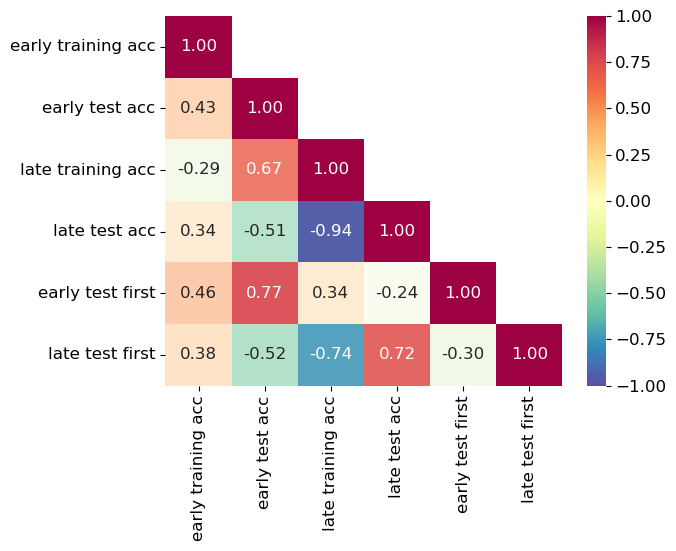

In [39]:
x_vars_of_interest = list(control_df.keys())
y_vars_of_interest = list(control_df.keys())

iu.plot_correlations(control_df, x_vars_of_interest, y_vars_of_interest)

In [28]:
print("p val control early training & early test")
print(pearsonr(control_early_training_accuracy, control_early_test_accuracy))

print("p val control early training & late training")
print(pearsonr(control_early_training_accuracy, control_late_training_accuracy))

print("p val control early test & late training")
print(pearsonr(control_early_test_accuracy, control_late_training_accuracy))

print("p val control early training & late test")
print(pearsonr(control_early_training_accuracy, control_late_test_accuracy))

print("p val control late training & late test")
print(pearsonr(control_late_training_accuracy, control_late_test_accuracy))

print("p val control early test & late test")
print(pearsonr(control_early_test_accuracy, control_late_test_accuracy))



p val control early training & early test
PearsonRResult(statistic=np.float64(0.4279539686731925), pvalue=np.float64(0.3381418185783816))
p val control early training & late training
PearsonRResult(statistic=np.float64(-0.2855484443639551), pvalue=np.float64(0.5347570278210849))
p val control early test & late training
PearsonRResult(statistic=np.float64(0.6680432720727094), pvalue=np.float64(0.10097415739077123))
p val control early training & late test
PearsonRResult(statistic=np.float64(0.33534681002388755), pvalue=np.float64(0.46216127063854856))
p val control late training & late test
PearsonRResult(statistic=np.float64(-0.9424486941275911), pvalue=np.float64(0.0014793430198355962))
p val control early test & late test
PearsonRResult(statistic=np.float64(-0.5060608273474739), pvalue=np.float64(0.24652758978205133))


In [40]:
cie_early_test_accuracy = plot_df[plot_df["trial_type"]=="early test"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
cie_late_test_accuracy = plot_df[plot_df["trial_type"]=="late test"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
cie_early_training_accuracy = plot_df[plot_df["detailed_trial_type"]=="early training"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
cie_late_training_accuracy = plot_df[plot_df["detailed_trial_type"]=="late training"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
cie_early_test_first_choice = plot_df[plot_df["trial"]==75][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
cie_late_test_first_choice = plot_df[plot_df["trial"]==155][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values

C:\Users\sarah\AppData\Local\Temp\ipykernel_9104\3960843070.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cie_early_test_accuracy = plot_df[plot_df["trial_type"]=="early test"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
C:\Users\sarah\AppData\Local\Temp\ipykernel_9104\3960843070.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cie_late_test_accuracy = plot_df[plot_df["trial_type"]=="late test"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
C:\Users\sarah\AppData\Local\Temp\ipykernel_9104\3960843070.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cie_early_training_accuracy = plot_df[plot_df["detailed_trial_type"]=="early training"][plot_df["group"]=="cie"].groupby(["animal"])["correct"].mean().values
C:\Users\sarah\AppData\Local\Temp\ipykernel_9104\3960843070.py:4: UserWarning: Boolean Series key will be reindexed to match DataF

In [41]:
cie_dict = {"early training acc": cie_early_training_accuracy, "early test acc": cie_early_test_accuracy, 
                "late training acc": cie_late_training_accuracy, "late test acc": cie_late_test_accuracy,
                "early test first": cie_early_test_first_choice, "late test first": cie_late_test_first_choice}

cie_df = pd.DataFrame(cie_dict)

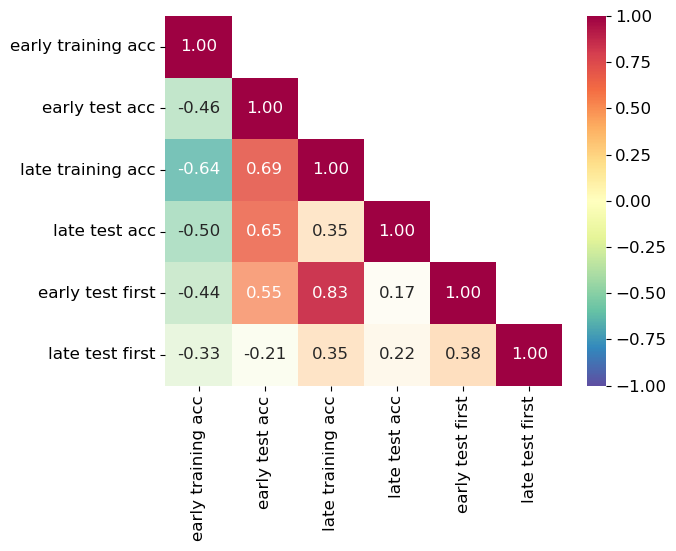

In [43]:
iu.plot_correlations(cie_df, x_vars_of_interest, y_vars_of_interest)

In [30]:
print("p val control early training & early test")
print(pearsonr(cie_early_training_accuracy, cie_early_test_accuracy))

print("p val control early training & late training")
print(pearsonr(cie_early_training_accuracy, cie_late_training_accuracy))

print("p val control early test & late training")
print(pearsonr(cie_early_test_accuracy, cie_late_training_accuracy))

print("p val control early training & late test")
print(pearsonr(cie_early_training_accuracy, cie_late_test_accuracy))

print("p val control late training & late test")
print(pearsonr(cie_late_training_accuracy, cie_late_test_accuracy))

print("p val control early test & late test")
print(pearsonr(cie_early_test_accuracy, cie_late_test_accuracy))


p val control early training & early test
PearsonRResult(statistic=np.float64(-0.4618493509774989), pvalue=np.float64(0.24929571222750618))
p val control early training & late training
PearsonRResult(statistic=np.float64(-0.6350855122976449), pvalue=np.float64(0.09066091302248637))
p val control early test & late training
PearsonRResult(statistic=np.float64(0.6947161607624154), pvalue=np.float64(0.055838074498051955))
p val control early training & late test
PearsonRResult(statistic=np.float64(-0.5026704642491095), pvalue=np.float64(0.20422477914296627))
p val control late training & late test
PearsonRResult(statistic=np.float64(0.3487234437215325), pvalue=np.float64(0.39721909796391547))
p val control early test & late test
PearsonRResult(statistic=np.float64(0.6527533657682196), pvalue=np.float64(0.07930926968941514))


In [31]:
plot_df[plot_df["group"]=="control"].groupby(["detailed_trial_type"])["correct"].var()

detailed_trial_type
early test        0.257143
early training    0.207684
late test         0.247059
late training     0.215921
Name: correct, dtype: float64

In [32]:
plot_df[plot_df["group"]=="cie"].groupby(["detailed_trial_type"])["correct"].var()

detailed_trial_type
early test        0.178846
early training    0.180957
late test         0.256410
late training     0.226352
Name: correct, dtype: float64